# Dataset × generator heatmaps

Load the experiment configuration and plot AUROC and TPR@1% FPR from the metadata stored in `results/*.npz`.

In [1]:
from pathlib import Path

from hydra import compose, initialize
from utils.configuration import list_detector_model_names, list_hydra_group_options
from utils.evaluation.ResultsReportGraphBuilder import plot_heatmap

/home/gx1/git/when-human-write-like-llm/when-human-write-like-machines/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
CONFIG_DIR = "conf"  # The notebook lives in the repository root.

detectors = list_hydra_group_options(CONFIG_DIR, "detector")
datasets = list_hydra_group_options(CONFIG_DIR, "dataset", ["base_dataset"])
detector_model_names = list_detector_model_names(CONFIG_DIR, "detector")

with initialize(version_base=None, config_path=CONFIG_DIR):
    cfg = compose(
        config_name="config",
        overrides=["detector=bert"],
    )

detectors, datasets, detector_model_names

(['bert', 'binoculars', 'fastdetectgpt', 'radar', 'roberta'],
 ['owt', 'wp', 'xsum'],
 ['BERT-Defense',
  'binoculars-falcon-7b',
  'FastDetectGPT',
  'radar',
  'RoBERTa-Defense'])

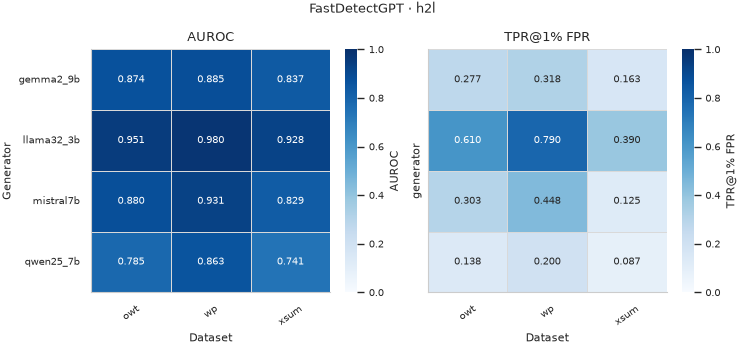

In [10]:
RESULTS_DIR = Path("results-aligned")

fig, axes, heatmap_rows = plot_heatmap(
    RESULTS_DIR,
    detector_name='FastDetectGPT',
    target_regime="h2l"
    # target_regime=cfg.machine_postfix,
)

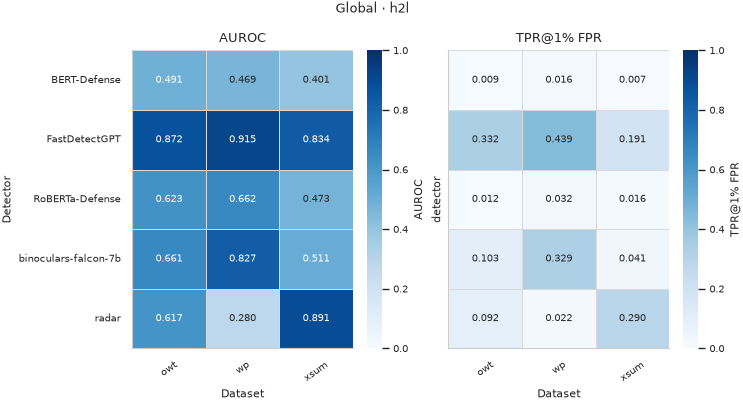

In [11]:
from utils.evaluation.ResultsReportGraphBuilder import plot_global_heatmap


global_fig, global_axes, global_rows = plot_global_heatmap("results", target_regime="h2l")

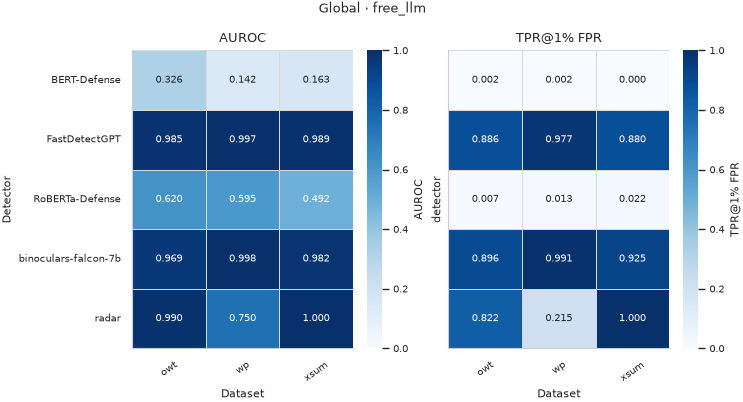

In [14]:
global_fig, global_axes, global_rows = plot_global_heatmap("results", target_regime="free_llm")

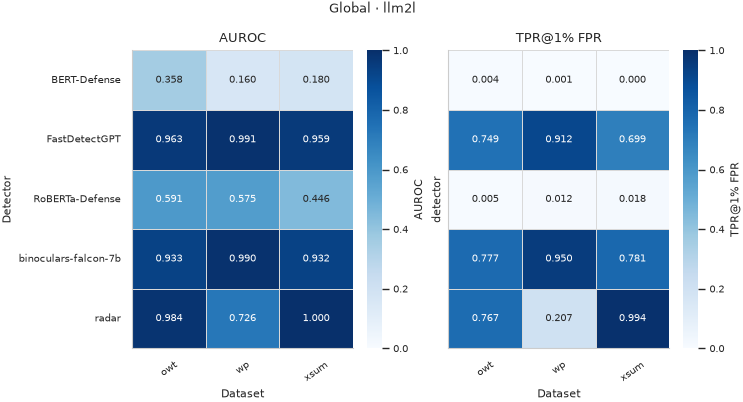

In [17]:
global_fig, global_axes, global_rows = plot_global_heatmap("results", target_regime="llm2l")

In [ ]:
heatmap_rows.drop(columns="path").sort_values(["generator", "dataset"])

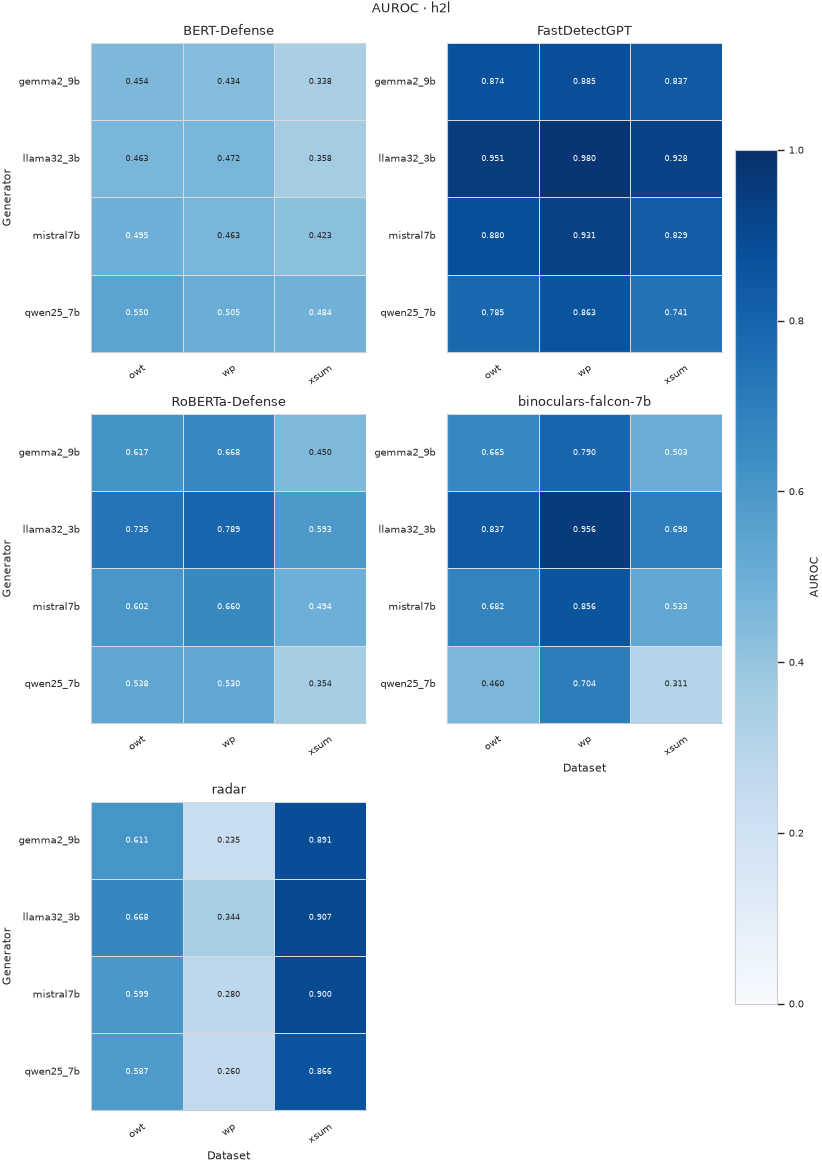

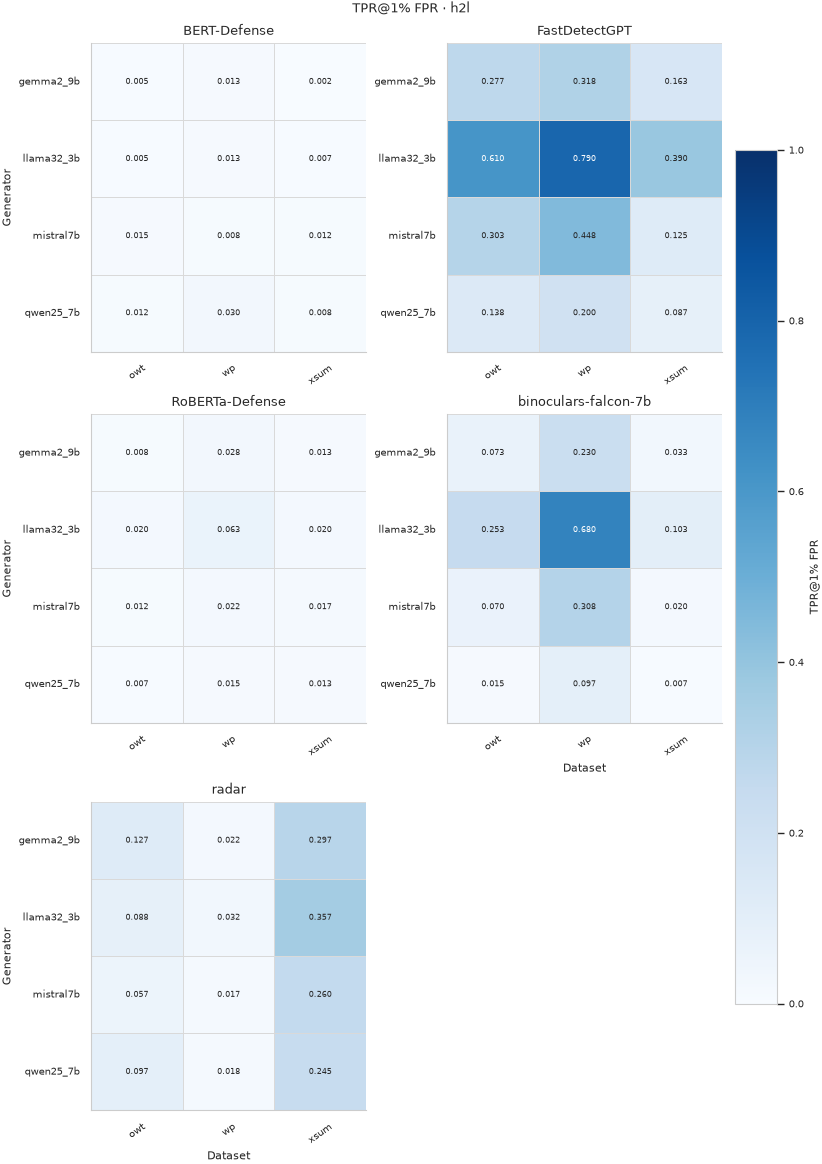

In [18]:
from utils.evaluation import plot_grid_heatmap

figures, axes, heatmap_rows = plot_grid_heatmap(
    RESULTS_DIR,
    target_regime="h2l",
    ncols=2,  # A4 verticale; usa 3 per A4 orizzontale
    output_path="results-aligned/figures/detector_grid",
    formats=("pdf", "png"),
)

### Analysis

Under H2L rewriting, FastDetectGPT is the most robust detector, achieving the highest AUROC and TPR@1%FPR across most dataset-generator combinations. Binoculars-falcon-7b shows competitive performance on WP but degrades substantially on OWT and especially XSum, indicating strong dataset sensitivity. Radar exhibits the opposite behavior: it achieves very high AUROC on XSum but only moderate TPR@1%FPR, suggesting good ranking but limited operational recall at strict false-positive rates. Supervised BERT/RoBERTa-based detectors are largely ineffective under H2L, particularly when evaluated at 1% FPR. Overall, the dominant source of variation appears to be the dataset rather than the generator, although FastDetectGPT and Binoculars show some generator sensitivity, with llama32_3b generally easier to detect and qwen25_7b often more challenging.

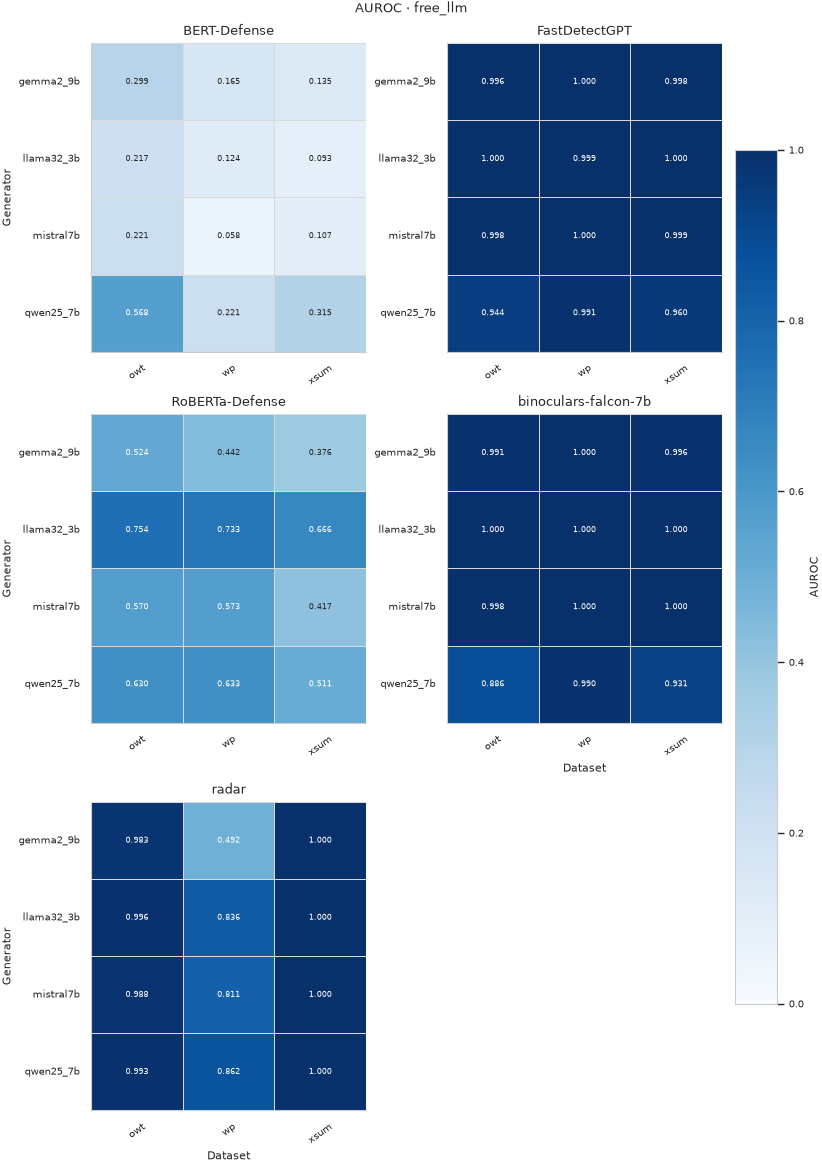

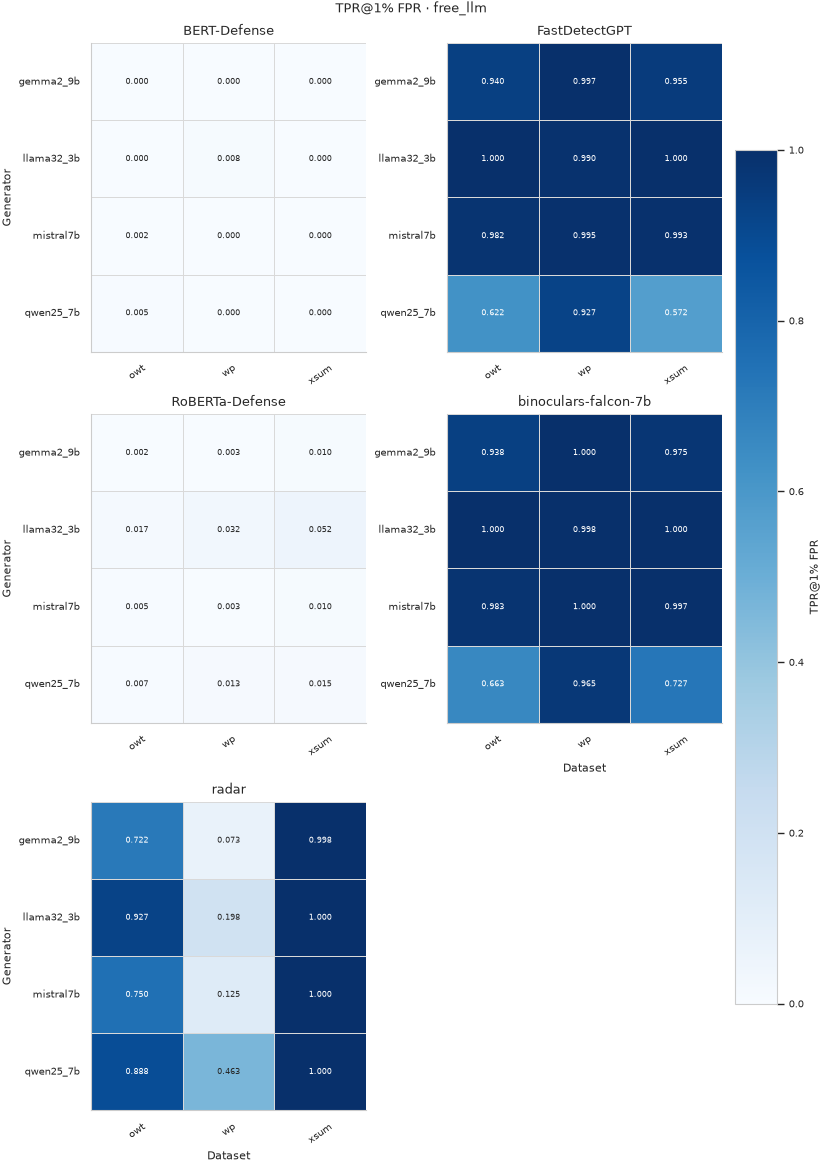

In [19]:
from utils.evaluation import plot_grid_heatmap

figures, axes, heatmap_rows = plot_grid_heatmap(
    RESULTS_DIR,
    target_regime="free_llm",
    ncols=2,  # A4 verticale; usa 3 per A4 orizzontale
    output_path="results-aligned/figures/detector_grid",
    formats=("pdf", "png"),
)

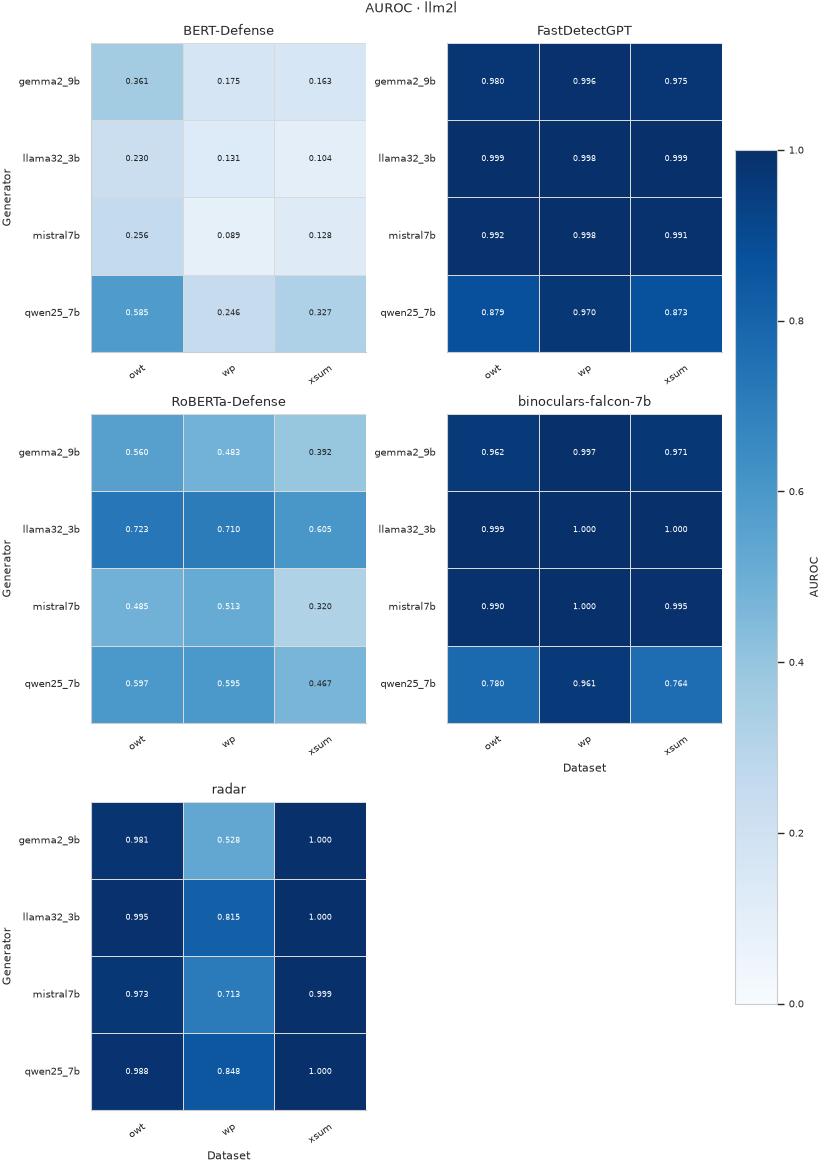

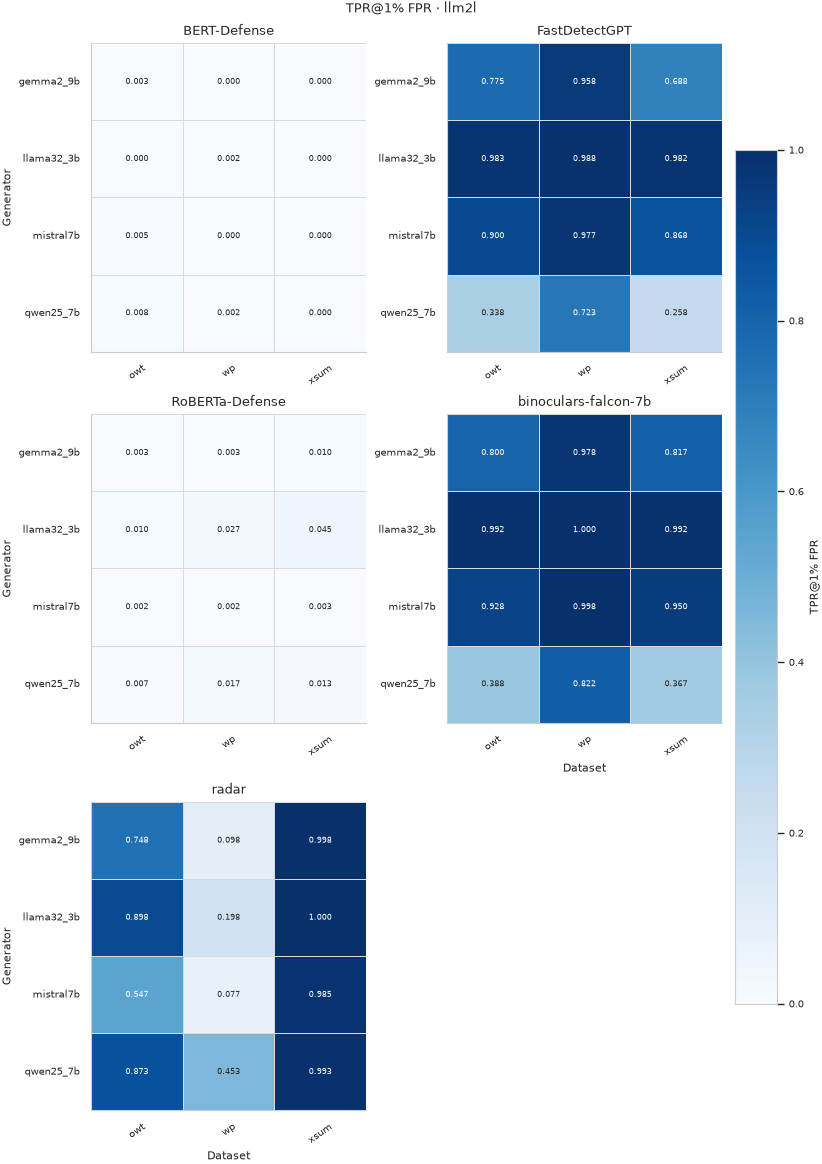

In [20]:
from utils.evaluation import plot_grid_heatmap

figures, axes, heatmap_rows = plot_grid_heatmap(
    RESULTS_DIR,
    target_regime="llm2l",
    ncols=2,  # A4 verticale; usa 3 per A4 orizzontale
    output_path="results-aligned/figures/detector_grid",
    formats=("pdf", "png"),
)

### Plot detection gap


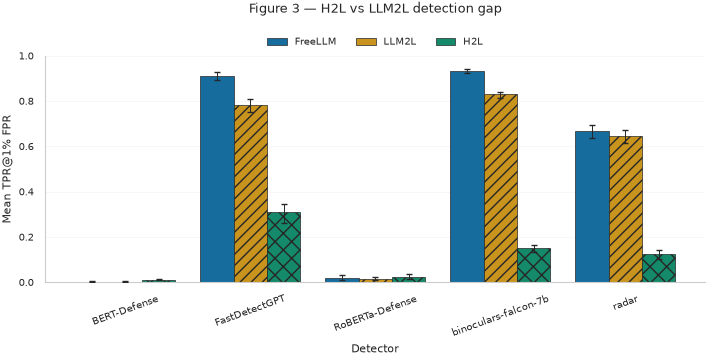

In [21]:
from utils.evaluation import plot_detection_gap_barplot

fig, ax, gap_rows = plot_detection_gap_barplot(
    RESULTS_DIR,
    n_bootstrap=5000,
    random_seed=42,
    alpha=0.05,
    output_path="results-aligned/figures/figure3_detection_gap",
    formats=("pdf", "png"),
)